
# Projet Machine Learning — Diabetes 130-US Hospitals

Ce notebook couvre l'ensemble des étapes demandées pour le projet :

1. **EDA**
2. **Cleaning**
3. **Feature Selection**
4. **Feature Extraction / Feature Engineering + PCA**
5. **Clustering**
6. **Ajout de la colonne de cluster au dataset**
7. **Entraînement d'un modèle de classification**

## Contexte du projet
Le descriptif du projet précise que le dataset choisi est **Diabetes 130-US Hospitals for Years 1999–2008**, avec comme variable cible `readmitted` (`<30`, `>30`, `NO`) et avec des objectifs qui combinent **apprentissage supervisé et non supervisé**. Le projet demande notamment du nettoyage, de la réduction de dimension, du clustering, puis une classification sur le dataset enrichi.





In [3]:

# =========================
# 1) Import des librairies
# =========================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    silhouette_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [4]:

# =========================
# 2) Chargement des données
# =========================
df = pd.read_csv("diabetes.csv", sep=";")
print("Shape initiale :", df.shape)
display(df.head())


Shape initiale : (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



## 1. EDA — Analyse exploratoire des données

Dans cette partie, on cherche à comprendre :
- la taille du dataset,
- les types de variables,
- les valeurs manquantes,
- la distribution de la cible,
- quelques relations simples entre les variables et la cible.


In [5]:

# Vue d'ensemble
print(df.info())
print("\nNombre de valeurs uniques par colonne :")
display(df.nunique().sort_values())


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

citoglipton                      1
examide                          1
acetohexamide                    2
glipizide-metformin              2
tolbutamide                      2
troglitazone                     2
metformin-rosiglitazone          2
glimepiride-pioglitazone         2
metformin-pioglitazone           2
change                           2
diabetesMed                      2
gender                           3
tolazamide                       3
readmitted                       3
max_glu_serum                    3
A1Cresult                        3
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
miglitol                         4
glimepiride                      4
metformin                        4
nateglinide                      4
repaglinide                      4
chlorpropamide                   4
glipizide                        4
glyburide                        4
insulin                          4
glyburide-metformin 

,column,missing_percent
0,weight,96.858479
1,max_glu_serum,94.746772
2,A1Cresult,83.277322
3,medical_specialty,49.082208
4,payer_code,39.557416
5,race,2.233555
6,diag_3,1.398306
7,diag_2,0.351787
8,diag_1,0.020636
9,patient_nbr,0.000000


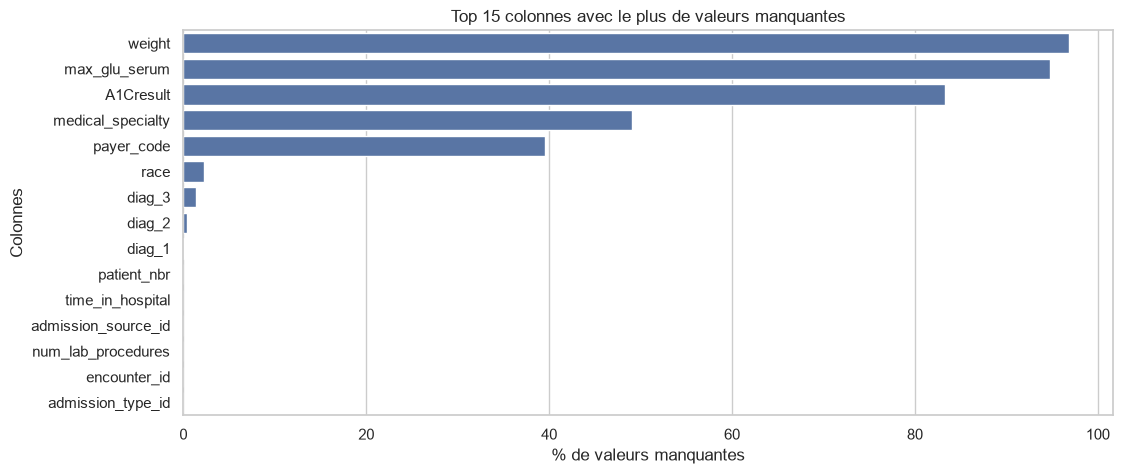

In [6]:

# On remplace les '?' par NaN pour mieux gérer les valeurs manquantes
df = df.replace("?", np.nan)

missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df = missing_ratio.reset_index()
missing_df.columns = ["column", "missing_percent"]

display(missing_df.head(15))

plt.figure(figsize=(12, 5))
sns.barplot(data=missing_df.head(15), x="missing_percent", y="column")
plt.title("Top 15 colonnes avec le plus de valeurs manquantes")
plt.xlabel("% de valeurs manquantes")
plt.ylabel("Colonnes")
plt.show()


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

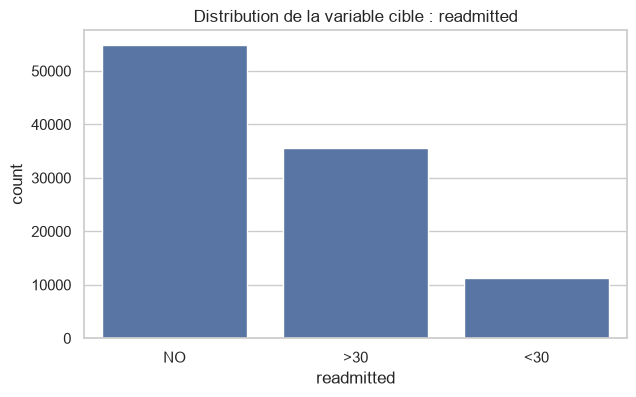

In [7]:

# Distribution de la cible
target_counts = df["readmitted"].value_counts()
display(target_counts)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="readmitted", order=target_counts.index)
plt.title("Distribution de la variable cible : readmitted")
plt.show()


In [8]:

# Séparation des colonnes numériques / catégorielles
numeric_cols_all = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols_all = df.select_dtypes(exclude=np.number).columns.tolist()

print("Colonnes numériques :", len(numeric_cols_all))
print("Colonnes catégorielles :", len(categorical_cols_all))
print("\nExemples numériques :", numeric_cols_all[:10])
print("\nExemples catégorielles :", categorical_cols_all[:10])


Colonnes numériques : 13
Colonnes catégorielles : 37

Exemples numériques : ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient']

Exemples catégorielles : ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum']


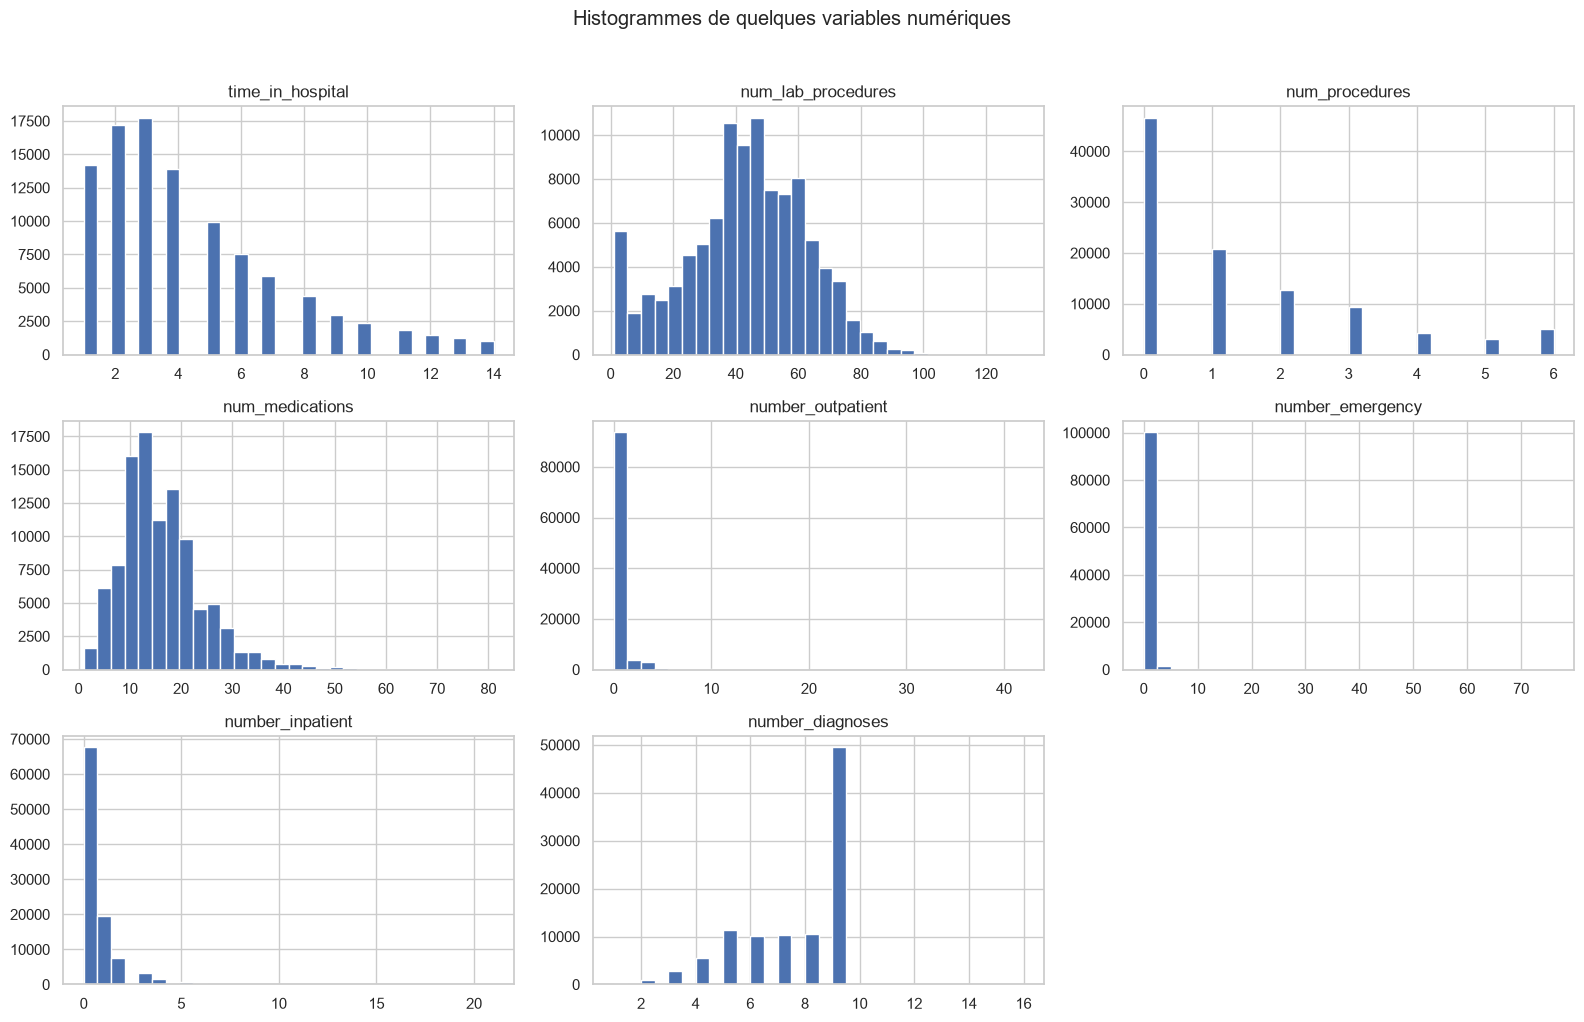

In [9]:

# Quelques distributions utiles
eda_num_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

available_eda_cols = [c for c in eda_num_cols if c in df.columns]

df[available_eda_cols].hist(bins=30, figsize=(16, 10))
plt.suptitle("Histogrammes de quelques variables numériques", y=1.02)
plt.tight_layout()
plt.show()


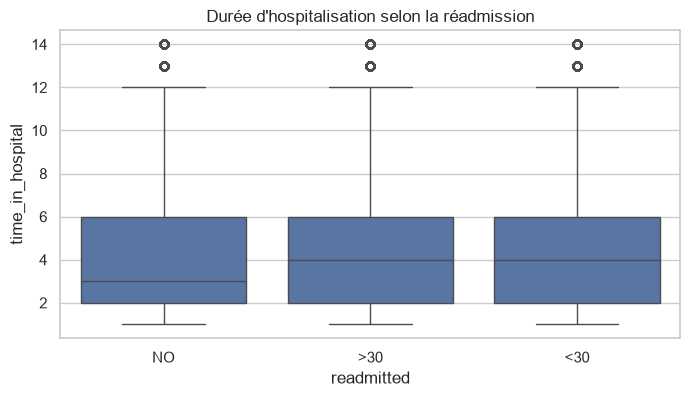

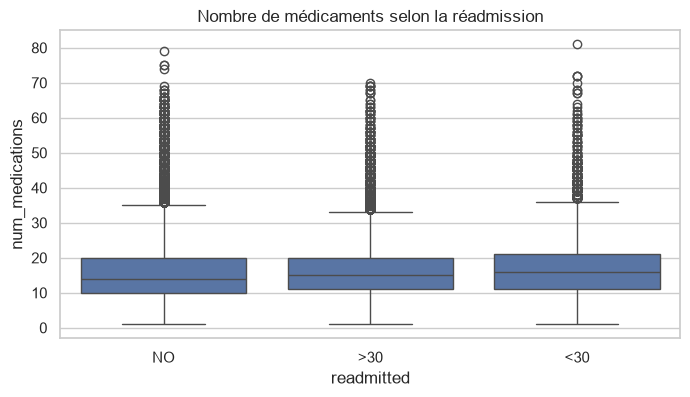

In [10]:

# Analyse simple par rapport à la cible
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="readmitted", y="time_in_hospital")
plt.title("Durée d'hospitalisation selon la réadmission")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="readmitted", y="num_medications")
plt.title("Nombre de médicaments selon la réadmission")
plt.show()



## 2. Cleaning

Choix de nettoyage appliqués :
- remplacer `?` par `NaN`,
- supprimer les colonnes identifiantes (`encounter_id`, `patient_nbr`) car elles n'apportent pas de signal prédictif,
- supprimer les colonnes avec **trop** de valeurs manquantes,
- supprimer les colonnes constantes,
- créer une base de travail propre.


In [11]:

# Colonnes à supprimer
missing_threshold = 0.40

high_missing_cols = df.columns[df.isna().mean() > missing_threshold].tolist()
low_variance_cols = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
id_cols = ["encounter_id", "patient_nbr"]

cols_to_drop = sorted(set(high_missing_cols + low_variance_cols + id_cols))

print("Colonnes à fort taux de valeurs manquantes :", high_missing_cols)
print("Colonnes constantes :", low_variance_cols)
print("Colonnes identifiantes :", id_cols)
print("\nTotal colonnes supprimées :", len(cols_to_drop))
print(cols_to_drop)

df_clean = df.drop(columns=cols_to_drop).copy()
print("\nNouvelle shape :", df_clean.shape)


Colonnes à fort taux de valeurs manquantes : ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Colonnes constantes : ['examide', 'citoglipton']
Colonnes identifiantes : ['encounter_id', 'patient_nbr']

Total colonnes supprimées : 8
['A1Cresult', 'citoglipton', 'encounter_id', 'examide', 'max_glu_serum', 'medical_specialty', 'patient_nbr', 'weight']

Nouvelle shape : (101766, 42)



## 3. Feature Selection

Ici, la sélection des variables se fait d'abord de façon **raisonnée** :
- suppression des identifiants,
- suppression des colonnes quasi inutiles (beaucoup trop de valeurs manquantes),
- suppression des colonnes constantes.

C'est une première forme de **feature selection** avant la modélisation.



## 4. Feature Engineering + PCA

Nous ajoutons des variables dérivées utiles :

- conversion de `age` (tranches) en une variable numérique `age_mid`,
- regroupement des diagnostics `diag_1`, `diag_2`, `diag_3` en grandes familles médicales,
- création de variables comme :
  - `service_utilization`
  - `total_procedures`
  - `medication_load`
  - `has_insulin`

Ensuite, nous appliquons une **PCA** sur les données préparées pour réduire la dimension avant le clustering.


In [12]:

# Conversion de la variable age en valeur numérique médiane
age_map = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df_fe = df_clean.copy()
df_fe["age_mid"] = df_fe["age"].map(age_map)

def group_diag(code):
    if pd.isna(code):
        return "Unknown"
    code = str(code)

    if code.startswith("V") or code.startswith("E"):
        return "Supplementary"

    try:
        code_float = float(code)
    except:
        return "Other"

    if 390 <= code_float <= 459 or code_float == 785:
        return "Circulatory"
    if 460 <= code_float <= 519 or code_float == 786:
        return "Respiratory"
    if 520 <= code_float <= 579 or code_float == 787:
        return "Digestive"
    if 250 <= code_float < 251:
        return "Diabetes"
    if 800 <= code_float <= 999:
        return "Injury"
    if 710 <= code_float <= 739:
        return "Musculoskeletal"
    if 580 <= code_float <= 629 or code_float == 788:
        return "Genitourinary"
    if 140 <= code_float <= 239:
        return "Neoplasms"

    return "Other"

for col in ["diag_1", "diag_2", "diag_3"]:
    df_fe[f"{col}_group"] = df_fe[col].apply(group_diag)

df_fe["service_utilization"] = (
    df_fe["number_outpatient"].fillna(0)
    + df_fe["number_emergency"].fillna(0)
    + df_fe["number_inpatient"].fillna(0)
)

df_fe["total_procedures"] = (
    df_fe["num_lab_procedures"].fillna(0)
    + df_fe["num_procedures"].fillna(0)
)

df_fe["medication_load"] = df_fe["num_medications"].fillna(0)

df_fe["has_insulin"] = (df_fe["insulin"].fillna("No") != "No").astype(int)

# On retire les colonnes redondantes après feature engineering
df_fe = df_fe.drop(columns=["age", "diag_1", "diag_2", "diag_3"])

print("Shape après feature engineering :", df_fe.shape)
display(df_fe.head())


Shape après feature engineering : (101766, 46)


,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,...,diabetesMed,readmitted,age_mid,diag_1_group,diag_2_group,diag_3_group,service_utilization,total_procedures,medication_load,has_insulin
0,Caucasian,Female,6,25,1,1,NaN,41,0,1,...,No,NO,5,Diabetes,Unknown,Unknown,0,41,1,0
1,Caucasian,Female,1,1,7,3,NaN,59,0,18,...,Yes,>30,15,Other,Diabetes,Other,0,59,18,1
2,AfricanAmerican,Female,1,1,7,2,NaN,11,5,13,...,Yes,NO,25,Other,Diabetes,Supplementary,3,16,13,0
3,Caucasian,Male,1,1,7,2,NaN,44,1,16,...,Yes,NO,35,Other,Diabetes,Circulatory,0,45,16,1
4,Caucasian,Male,1,1,7,1,NaN,51,0,8,...,Yes,NO,45,Neoplasms,Neoplasms,Diabetes,0,51,8,1


In [13]:

# Préparation pour le clustering
X_unsup = df_fe.drop(columns=["readmitted"]).copy()

cat_cols_unsup = X_unsup.select_dtypes(include="object").columns.tolist()
num_cols_unsup = X_unsup.select_dtypes(exclude="object").columns.tolist()

cluster_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols_unsup
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
            ]),
            cat_cols_unsup
        )
    ]
)

# Pour la recherche de k, on utilise un échantillon raisonnable
cluster_sample_size = min(8000, len(X_unsup))
X_cluster_sample = X_unsup.sample(cluster_sample_size, random_state=RANDOM_STATE)

X_cluster_sample_prepared = cluster_preprocessor.fit_transform(X_cluster_sample)

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_cluster_sample_pca = pca.fit_transform(X_cluster_sample_prepared)

print("Shape avant PCA :", X_cluster_sample_prepared.shape)
print("Shape après PCA :", X_cluster_sample_pca.shape)
print("Variance expliquée cumulée :", round(pca.explained_variance_ratio_.sum(), 4))


Shape avant PCA : (8000, 45)
Shape après PCA : (8000, 12)
Variance expliquée cumulée : 0.9014


In [14]:

# Choix du nombre de clusters avec le score de silhouette
silhouette_scores = {}

for k in range(2, 5):
    kmeans_tmp = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=1024,
        n_init=10
    )
    labels_tmp = kmeans_tmp.fit_predict(X_cluster_sample_pca)
    score = silhouette_score(
        X_cluster_sample_pca,
        labels_tmp,
        sample_size=min(2000, len(X_cluster_sample_pca)),
        random_state=RANDOM_STATE
    )
    silhouette_scores[k] = score

silhouette_scores


{2: 0.20138787266093136, 3: 0.18461401946063588, 4: 0.18497847002656026}

In [15]:

best_k = max(silhouette_scores, key=silhouette_scores.get)
print("Meilleur nombre de clusters selon la silhouette :", best_k)
print("Score associé :", silhouette_scores[best_k])


Meilleur nombre de clusters selon la silhouette : 2
Score associé : 0.20138787266093136



## 5. Clustering

Une fois le nombre de clusters choisi, on :
- prépare tout le dataset,
- applique la PCA,
- entraîne le modèle de clustering,
- récupère les labels de clusters.


Répartition des clusters :


0    48755
1    53011
Name: count, dtype: int64

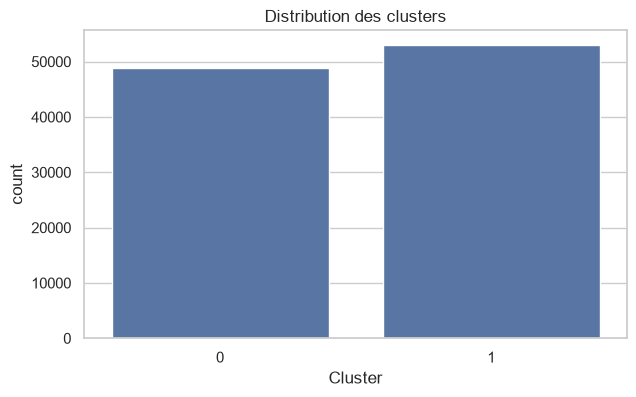

In [16]:

# Entraînement final du clustering sur tout le dataset
X_unsup_prepared = cluster_preprocessor.fit_transform(X_unsup)

pca_final = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_unsup_pca = pca_final.fit_transform(X_unsup_prepared)

kmeans_final = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    batch_size=2048,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_unsup_pca)

print("Répartition des clusters :")
display(pd.Series(clusters).value_counts().sort_index())

plt.figure(figsize=(7, 4))
sns.countplot(x=clusters)
plt.title("Distribution des clusters")
plt.xlabel("Cluster")
plt.show()



## 6. Ajout de la colonne de cluster au dataset

C'est une étape importante car elle permet d'utiliser l'information non supervisée comme nouvelle variable explicative dans le modèle supervisé.


In [17]:

df_final = df_fe.copy()
df_final["cluster"] = clusters

print("Shape finale :", df_final.shape)
display(df_final.head())

# Sauvegarde du dataset enrichi
df_final.to_csv("diabetes_with_clusters.csv", index=False)
print("Fichier sauvegardé : diabetes_with_clusters.csv")


Shape finale : (101766, 47)


,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,...,readmitted,age_mid,diag_1_group,diag_2_group,diag_3_group,service_utilization,total_procedures,medication_load,has_insulin,cluster
0,Caucasian,Female,6,25,1,1,NaN,41,0,1,...,NO,5,Diabetes,Unknown,Unknown,0,41,1,0,0
1,Caucasian,Female,1,1,7,3,NaN,59,0,18,...,>30,15,Other,Diabetes,Other,0,59,18,1,1
2,AfricanAmerican,Female,1,1,7,2,NaN,11,5,13,...,NO,25,Other,Diabetes,Supplementary,3,16,13,0,1
3,Caucasian,Male,1,1,7,2,NaN,44,1,16,...,NO,35,Other,Diabetes,Circulatory,0,45,16,1,0
4,Caucasian,Male,1,1,7,1,NaN,51,0,8,...,NO,45,Neoplasms,Neoplasms,Diabetes,0,51,8,1,0


Fichier sauvegardé : diabetes_with_clusters.csv



## 7. Entraînement d'un modèle de classification

On entraîne ici un modèle pour prédire `readmitted` à partir du dataset enrichi par la colonne `cluster`.

### Choix de modélisation
Pour garder une exécution raisonnable :
- on prend un échantillon stratifié,
- on applique un prétraitement adapté,
- on utilise une **régression logistique** multiclasses comme baseline sérieuse et facile à expliquer.

> Tu peux ensuite remplacer ce modèle par Random Forest, XGBoost, LightGBM ou CatBoost si ton enseignant veut une version plus avancée.


In [18]:

# Échantillon stratifié pour accélérer la classification
samples_per_class = {
    "NO": 16000,
    ">30": 10000,
    "<30": 4000
}

parts = []
for label, n in samples_per_class.items():
    subset = df_final[df_final["readmitted"] == label]
    parts.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))

df_cls = pd.concat(parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Shape de l'échantillon de classification :", df_cls.shape)
display(df_cls["readmitted"].value_counts())


Shape de l'échantillon de classification : (30000, 47)


readmitted
NO     16000
>30    10000
<30     4000
Name: count, dtype: int64

In [19]:

X = df_cls.drop(columns=["readmitted"])
y = df_cls["readmitted"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

clf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            num_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ]
)

clf_model = Pipeline([
    ("preprocessor", clf_preprocessor),
    ("classifier", LogisticRegression(max_iter=200))
])

clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", round(acc, 4))
print("F1-score pondéré :", round(f1, 4))


Accuracy : 0.5595
F1-score pondéré : 0.4877


In [20]:

print("Rapport de classification :")
print(classification_report(y_test, y_pred))


Rapport de classification :
              precision    recall  f1-score   support

         <30       0.45      0.03      0.05       800
         >30       0.46      0.24      0.31      2000
          NO       0.58      0.89      0.70      3200

    accuracy                           0.56      6000
   macro avg       0.50      0.39      0.36      6000
weighted avg       0.52      0.56      0.49      6000



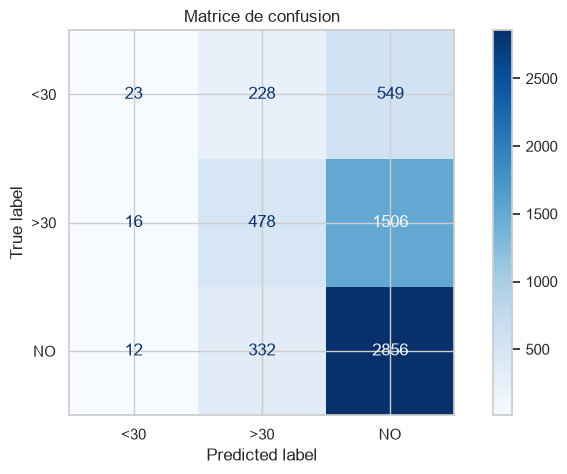

In [21]:

cm = confusion_matrix(y_test, y_pred, labels=clf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_model.classes_)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()



## Conclusion

Ce notebook répond à ces étapes demandées :

- **EDA** : exploration du dataset, valeurs manquantes, distributions
- **Cleaning** : traitement des `?`, suppression de colonnes non pertinentes
- **Feature Selection** : suppression raisonnée des variables peu utiles
- **Feature Engineering + PCA** : création de variables dérivées + réduction de dimension
- **Clustering** : segmentation des patients en groupes
- **Ajout du cluster** : enrichissement du dataset
- **Classification** : entraînement d'un modèle de prédiction de `readmitted`


